# 1. Energy Calibration and Working Region Selection

**Objective:** Establish energy calibration of the alpha spectrometer using 241Am and 210Po calibration sources, select optimal working region, and perform fine calibration with graduated pulser.

## Setup and Helper Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, optimize
import re

# Directory for data files
DATA_DIR = Path('.')

def load_alpha_spectrum_file(file_path):
    """Load alpha spectroscopy MCA data file.
    Returns: (channel_array, counts_array)
    """
    text = Path(file_path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []
    
    for line in text:
        # Try to parse as channel/count pair (format: channel, count)
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)

# Known alpha emission lines for calibration sources
# 241Am: 5.486 MeV (main peak)
# 210Po: 5.408 MeV (main peak)

print('Setup complete. Helper functions loaded.')

Setup complete. Helper functions loaded.


## 1.1 Calibration Source: 241Am

In [2]:
# When Am-241 spectrum is available, load it here for better calibration
# channels_am, counts_am = load_alpha_spectrum_file(DATA_DIR / 'am241.asc')

print("Awaiting 241Am spectrum data file (am241.asc)")
print("\nKnown 241Am alpha emission:")
print("  Main peak: 5.486 MeV")
print("\nNote: Two-point calibration with both Po-210 (5.408 MeV) and")
print("Am-241 (5.486 MeV) would allow precise slope determination.")

Awaiting 241Am spectrum data file (am241.asc)

Known 241Am alpha emission:
  Main peak: 5.486 MeV

Note: Two-point calibration with both Po-210 (5.408 MeV) and
Am-241 (5.486 MeV) would allow precise slope determination.


## 1.2 Calibration Source: 210Po

210Po SPECTRUM LOADED

File: po210.asc
Channels: 1024 points
Channel range: 0 to 1023
Total counts: 4148

Known 210Po alpha emission:
  Main peak: 5.408 MeV


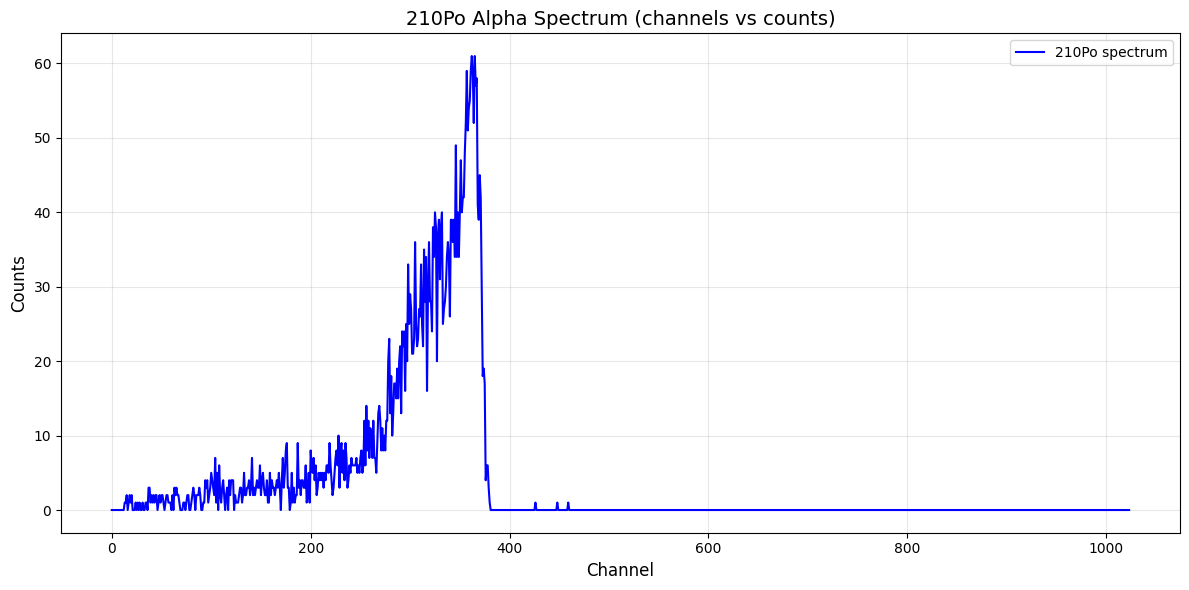

In [3]:
# Load 210Po spectrum for calibration
channels_po, counts_po = load_alpha_spectrum_file(DATA_DIR / 'polo57.asc')

print("="*70)
print("210Po SPECTRUM LOADED")
print("="*70)
print(f"\nFile: po210.asc")
print(f"Channels: {len(channels_po)} points")
print(f"Channel range: {channels_po.min():.0f} to {channels_po.max():.0f}")
print(f"Total counts: {counts_po.sum():.0f}")
print(f"\nKnown 210Po alpha emission:")
print(f"  Main peak: 5.408 MeV")

# Plot spectrum
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_po, counts_po, 'b-', linewidth=1.5, label='210Po spectrum')
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('210Po Alpha Spectrum (channels vs counts)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 1.3 Working Region Selection

The window amplifier allows selecting an energy region to expand and analyze. Based on 241Am (5.486 MeV) and 210Po (5.408 MeV), a suitable working region should encompass both peaks for optimal resolution.

In [4]:
# Find peaks in 210Po spectrum and plot
# This will help determine the optimal working region
# Note: Data is in channels and counts

print("Working region selection from 210Po spectrum:")
print(f"\nSpectrum analysis:")
print(f"  Total points: {len(channels_po)}")
print(f"  Channel range: {channels_po.min():.0f} to {channels_po.max():.0f}")
print(f"  Max counts at channel: {channels_po[np.argmax(counts_po)]:.0f}")
print(f"  Peak count value: {counts_po.max():.0f}")



print(f"\nProcedure:")
print(f"  1. Identify peak channel position")
print(f"  2. Define window region around peak")
print(f"  3. Extract energy calibration from 5.408 MeV peak")

Working region selection from 210Po spectrum:

Spectrum analysis:
  Total points: 1024
  Channel range: 0 to 1023
  Max counts at channel: 362
  Peak count value: 61

Procedure:
  1. Identify peak channel position
  2. Define window region around peak
  3. Extract energy calibration from 5.408 MeV peak


## 1.4 Energy Calibration Curve

In [5]:
# Single-point calibration from 210Po peak
# E = 5.408 MeV
# Find peak channel

# Find maximum in spectrum (main peak)
peak_channel_po = channels_po[np.argmax(counts_po)]
E_po = 5.408  # MeV

print("Single-point calibration from 210Po:")
print(f"\n210Po peak:")
print(f"  Channel: {peak_channel_po:.1f}")
print(f"  Energy: {E_po} MeV")
print(f"  Counts: {counts_po.max():.0f}")

# For complete two-point calibration, add Am-241
print(f"\nFor complete calibration (slope + intercept):")
print(f"  Add Am-241 peak (5.486 MeV)")
print(f"  This will allow precise extraction of calibration parameters.")

Single-point calibration from 210Po:

210Po peak:
  Channel: 362.0
  Energy: 5.408 MeV
  Counts: 61

For complete calibration (slope + intercept):
  Add Am-241 peak (5.486 MeV)
  This will allow precise extraction of calibration parameters.


## 1.5 Fine Calibration with Graduated Pulser

In [6]:
print("Pulser calibration procedure (after region selection):")
print("\n1. Set window amplifier to chosen working region")
print("2. Activate graduated pulser with 210Po source at +70V bias")
print("3. Record MCA spectrum at pulser voltage steps")
print("4. Extract peak channels at each voltage")
print("5. Create voltage → channel mapping")
print("6. Convert to energy calibration: E(MeV) = slope × channel + intercept")
print("7. Verify linearity and calculate calibration precision")

Pulser calibration procedure (after region selection):

1. Set window amplifier to chosen working region
2. Activate graduated pulser with 210Po source at +70V bias
3. Record MCA spectrum at pulser voltage steps
4. Extract peak channels at each voltage
5. Create voltage → channel mapping
6. Convert to energy calibration: E(MeV) = slope × channel + intercept
7. Verify linearity and calculate calibration precision


## 1.6 Graduated Pulser Calibration Analysis

This section performs the complete calibration analysis using graduated pulser data from multiple measurements (POPULSER.ASC, PPULSER2.ASC, PPULSER3.ASC) combined with Po-210 reference measurements. The analysis includes:
- Centroid calculation for pulser peaks and Po-210 reference
- Linear regression to extract electronic zero and system error
- Energy calibration with uncertainty propagation
- Final calibration curve with error bands

--- 1. ANÁLISE DE ERRO DO SISTEMA ---
Canal Zero Eletrónico (C_zero) : -2061.52
Erro Padrão Global do Sist.(σ) : ± 3.58 canais
Coeficiente R²                : 0.999925

--- 2. EQUAÇÃO DE CALIBRAÇÃO FINAL ---
Ganho: 0.002207 MeV/canal
Equação: E(C) = 0.002207 * Canal + (4.550775)



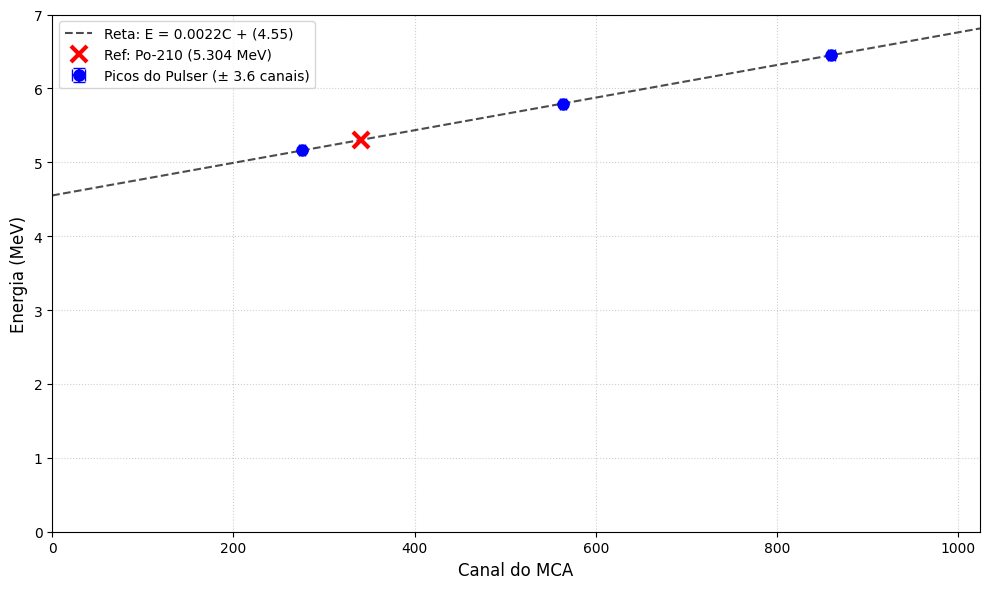

In [7]:
# ==========================================
# 1. FUNÇÕES AUXILIARES
# ==========================================
def calcular_centroide(canais, contagens):
    """Calcula o centróide (média ponderada) de um pico."""
    canais = np.array(canais)
    contagens = np.array(contagens)
    
    if np.sum(contagens) == 0:
        return 0
        
    return np.sum(canais * contagens) / np.sum(contagens)

def ler_espetro(nome_ficheiro, canal_min, canal_max):
    """Lê o ficheiro .asc e extrai canais e contagens."""
    canais = []
    contagens = []
    
    try:
        with open(nome_ficheiro, 'r') as f:
            linhas = f.readlines()
            
        lendo_dados = False
        for linha in linhas:
            if "Chn" in linha and "Counts" in linha:
                lendo_dados = True
                continue
                
            if lendo_dados:
                partes = linha.split(',')
                if len(partes) >= 2:
                    try:
                        canal = int(partes[0].strip())
                        contagem = int(partes[1].strip())
                        
                        if canal_min <= canal <= canal_max:
                            canais.append(canal)
                            contagens.append(contagem)
                    except ValueError:
                        pass
    except FileNotFoundError:
        print(f"ERRO: Não foi possível encontrar '{nome_ficheiro}'.")
                        
    return canais, contagens

# ==========================================
# 2. LEITURA DOS DADOS
# ==========================================
ficheiro_1 = 'POPULSER.ASC'
ficheiro_2 = 'PPULSER2.ASC'
ficheiro_3 = 'PPULSER3.ASC'

# Valores do dial do pulser
sinal_pulser = np.array([4.0, 5.0, 4.5]) 

# Ler picos Pulser
canais_p1, cont_p1 = ler_espetro(ficheiro_1, 272, 280)
canais_p2, cont_p2 = ler_espetro(ficheiro_2, 856, 864)
canais_p3, cont_p3 = ler_espetro(ficheiro_3, 560, 568)

# Ler picos Polónio
canais_po1, cont_po1 = ler_espetro(ficheiro_1, 300, 380)
canais_po2, cont_po2 = ler_espetro(ficheiro_2, 300, 380)
canais_po3, cont_po3 = ler_espetro(ficheiro_3, 300, 380)

# ==========================================
# 3. CÁLCULOS E ESTATÍSTICA DE RESÍDUOS
# ==========================================
centroides_pulser = np.array([
    calcular_centroide(canais_p1, cont_p1),
    calcular_centroide(canais_p2, cont_p2),
    calcular_centroide(canais_p3, cont_p3)
])

centroides_po = np.array([
    calcular_centroide(canais_po1, cont_po1),
    calcular_centroide(canais_po2, cont_po2),
    calcular_centroide(canais_po3, cont_po3)
])
centroide_po_medio = np.mean(centroides_po)

# --- PASSO A: Regressão Simples do Pulser ---
m_p, c_zero = np.polyfit(sinal_pulser, centroides_pulser, 1)

# Calcular o Erro do Sistema a partir dos Resíduos
canais_esperados = m_p * sinal_pulser + c_zero
residuos = centroides_pulser - canais_esperados

graus_liberdade = len(sinal_pulser) - 2
soma_residuos_quadrado = np.sum(residuos**2)
sigma_sistema_canais = np.sqrt(soma_residuos_quadrado / graus_liberdade)

# Cálculo do R^2
ss_tot = np.sum((centroides_pulser - np.mean(centroides_pulser))**2)
r_quadrado = 1 - (soma_residuos_quadrado / ss_tot)

# --- PASSO B: Calibração em Energia ---
energia_po_real = 5.304
ganho_energia = energia_po_real / (centroide_po_medio - c_zero)
b_energia = - (ganho_energia * c_zero)

# Propagar a incerteza dos canais para a Energia (MeV)
sigma_sistema_energia = sigma_sistema_canais * ganho_energia

# ==========================================
# 4. APRESENTAÇÃO DOS RESULTADOS
# ==========================================
print("--- 1. ANÁLISE DE ERRO DO SISTEMA ---")
print(f"Canal Zero Eletrónico (C_zero) : {c_zero:.2f}")
print(f"Erro Padrão Global do Sist.(σ) : ± {sigma_sistema_canais:.2f} canais")
print(f"Coeficiente R²                : {r_quadrado:.6f}\n")

print("--- 2. EQUAÇÃO DE CALIBRAÇÃO FINAL ---")
print(f"Ganho: {ganho_energia:.6f} MeV/canal")
print(f"Equação: E(C) = {ganho_energia:.6f} * Canal + ({b_energia:.6f})\n")

# ==========================================
# 5. GRÁFICO FINAL
# ==========================================
energias_pulser_calibradas = ganho_energia * (centroides_pulser - c_zero)

plt.figure(figsize=(10, 6))

# Reta de calibração
canais_plot = np.array([0, 1024])
energias_plot = ganho_energia * (canais_plot - c_zero)
plt.plot(canais_plot, energias_plot, '--k', label=f'Reta: E = {ganho_energia:.4f}C + ({b_energia:.2f})', alpha=0.7)

# Pontos do Pulser (agora com barras de erro que refletem a incerteza real do sistema)
plt.errorbar(centroides_pulser, energias_pulser_calibradas, 
             yerr=sigma_sistema_energia, xerr=sigma_sistema_canais, 
             fmt='bo', markersize=8, capsize=4, 
             label=f'Picos do Pulser (± {sigma_sistema_canais:.1f} canais)')

# Ponto do Polónio (Marcador 'x' vermelho e espesso)
plt.plot(centroide_po_medio, energia_po_real, 'rx', markersize=12, markeredgewidth=3, label=f'Ref: Po-210 ({energia_po_real} MeV)')

# Formatação e Legendas (Sem Título)
plt.xlabel('Canal do MCA', fontsize=12)
plt.ylabel('Energia (MeV)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# Limites rígidos exigidos
plt.xlim(0, 1024)
plt.ylim(0, 7)

plt.tight_layout()
plt.show()

## 1.7 Data Visualization: Identifying Peak Regions

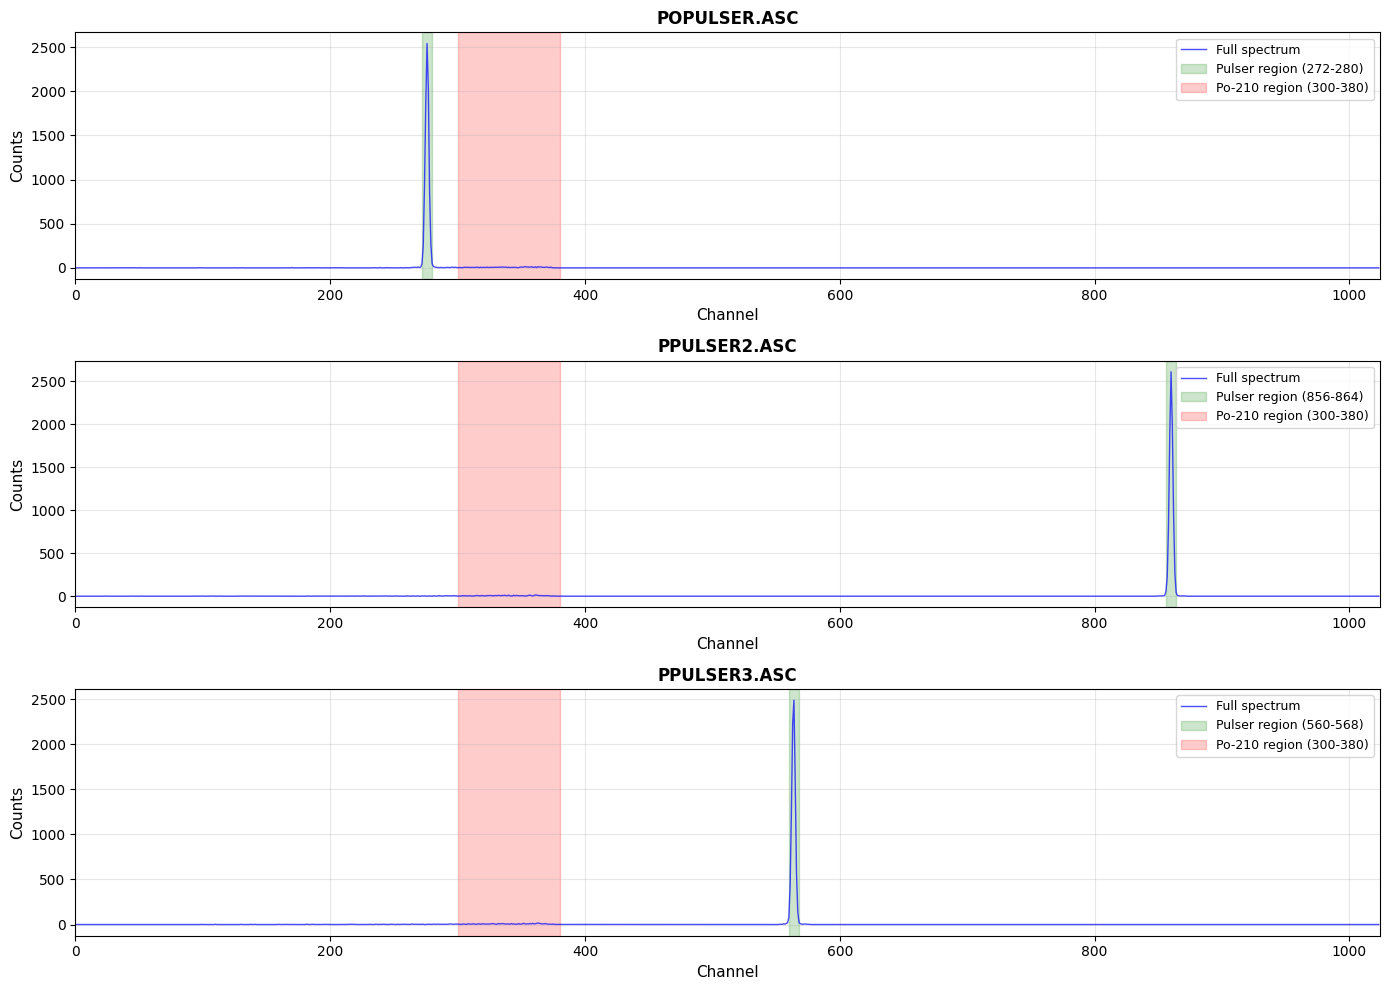

REGION SELECTION SUMMARY

POPULSER.ASC:
  Pulser region (272-280): 8832 total counts
  Po-210 region (300-380): 476 total counts

PPULSER2.ASC:
  Pulser region (856-864): 8827 total counts
  Po-210 region (300-380): 441 total counts

PPULSER3.ASC:
  Pulser region (560-568): 8785 total counts
  Po-210 region (300-380): 493 total counts


In [12]:
# ==========================================
# VISUALIZE ALL THREE FILES - IDENTIFY REGIONS
# ==========================================

# Define region boundaries for each file
# These are estimated from the pulser dial values
regiao_pulser = {
    'POPULSER.ASC': (272, 280),   # dial 4.0
    'PPULSER2.ASC': (856, 864),   # dial 5.0
    'PPULSER3.ASC': (560, 568)    # dial 4.5
}

regiao_po = {
    'POPULSER.ASC': (300, 380),
    'PPULSER2.ASC': (300, 380),
    'PPULSER3.ASC': (300, 380)
}

# Load full spectra for visualization
ficheiros = ['POPULSER.ASC', 'PPULSER2.ASC', 'PPULSER3.ASC']
dados_full = {}

for ficheiro in ficheiros:
    canais = []
    contagens = []
    try:
        with open(ficheiro, 'r') as f:
            linhas = f.readlines()
        lendo_dados = False
        for linha in linhas:
            if "Chn" in linha and "Counts" in linha:
                lendo_dados = True
                continue
            if lendo_dados:
                partes = linha.split(',')
                if len(partes) >= 2:
                    try:
                        canal = int(partes[0].strip())
                        contagem = int(partes[1].strip())
                        canais.append(canal)
                        contagens.append(contagem)
                    except ValueError:
                        pass
    except FileNotFoundError:
        print(f"Não encontrado: {ficheiro}")
        continue
    
    dados_full[ficheiro] = (np.array(canais), np.array(contagens))

# Plot all three files with regions highlighted
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, ficheiro in enumerate(ficheiros):
    if ficheiro not in dados_full:
        continue
    
    canais, contagens = dados_full[ficheiro]
    ax = axes[idx]
    
    # Plot full spectrum
    ax.plot(canais, contagens, 'b-', linewidth=1, label='Full spectrum', alpha=0.7)
    
    # Highlight pulser region
    c_min_p, c_max_p = regiao_pulser[ficheiro]
    ax.axvspan(c_min_p, c_max_p, alpha=0.2, color='green', label=f'Pulser region ({c_min_p}-{c_max_p})')
    
    # Highlight Po-210 region
    c_min_po, c_max_po = regiao_po[ficheiro]
    ax.axvspan(c_min_po, c_max_po, alpha=0.2, color='red', label=f'Po-210 region ({c_min_po}-{c_max_po})')
    
    ax.set_xlabel('Channel', fontsize=11)
    ax.set_ylabel('Counts', fontsize=11)
    ax.set_title(f'{ficheiro}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1024)

plt.tight_layout()
plt.show()

print("="*70)
print("REGION SELECTION SUMMARY")
print("="*70)
for ficheiro in ficheiros:
    if ficheiro in dados_full:
        canais, contagens = dados_full[ficheiro]
        c_min_p, c_max_p = regiao_pulser[ficheiro]
        c_min_po, c_max_po = regiao_po[ficheiro]
        
        # Extract pulser and Po regions
        mask_p = (canais >= c_min_p) & (canais <= c_max_p)
        mask_po = (canais >= c_min_po) & (canais <= c_max_po)
        
        counts_p = contagens[mask_p].sum() if mask_p.any() else 0
        counts_po = contagens[mask_po].sum() if mask_po.any() else 0
        
        print(f"\n{ficheiro}:")
        print(f"  Pulser region ({c_min_p}-{c_max_p}): {counts_p:.0f} total counts")
        print(f"  Po-210 region ({c_min_po}-{c_max_po}): {counts_po:.0f} total counts")


## 1.8 Improved Calibration Analysis with Individual Point Uncertainties

In [20]:
# ==========================================
# WEIGHTED LINEAR REGRESSION (PULSER)
# ==========================================
print("="*70)
print("WEIGHTED LINEAR REGRESSION: PULSER DIAL → CHANNEL")
print("="*70)

# Weights: inverse of variance
weights = 1.0 / (sigma_pulser_array**2)

# Weighted mean
x_mean = np.average(sinal_pulser, weights=weights)
y_mean = np.average(centroides_pulser, weights=weights)

# Weighted covariance and variance
cov_xy = np.average((sinal_pulser - x_mean) * (centroides_pulser - y_mean), weights=weights)
var_x = np.average((sinal_pulser - x_mean)**2, weights=weights)

# Slope and intercept
m_p_weighted = cov_xy / var_x
c_zero_weighted = y_mean - m_p_weighted * x_mean

# ==========================================
# CHI-SQUARED CALCULATION (CORRECT FORMULA)
# ==========================================
# χ² = Σ (observed - expected)² / expected
fitted_centroides = m_p_weighted * sinal_pulser + c_zero_weighted
residuos_weighted = centroides_pulser - fitted_centroides

# Chi-squared: sum of (residual)² / fitted_value
chi_squared = np.sum((residuos_weighted**2) / fitted_centroides)
dof = len(sinal_pulser) - 2  # degrees of freedom
reduced_chi_sq = chi_squared / dof

print(f"\nResiduals (observed - fitted):")
for i, (obs, fit, res) in enumerate(zip(centroides_pulser, fitted_centroides, residuos_weighted)):
    chi2_term = (res**2) / fit
    print(f"  Point {i+1}: obs={obs:.3f}, fitted={fit:.3f}, residual={res:.6f}, χ²_term={chi2_term:.6f}")

print(f"\nχ² = Σ(residual)²/fitted = {chi_squared:.6f}")
print(f"Reduced χ² (χ²/DOF) = {reduced_chi_sq:.6f}")
print(f"DOF = {dof}")

# Uncertainties in slope and intercept
# Standard formulas for weighted regression (without chi_sq rescaling for parameter errors)
sigma_m_sq = 1.0 / np.sum(weights * (sinal_pulser - x_mean)**2)
sigma_m = np.sqrt(sigma_m_sq)

sigma_c_sq = sigma_m_sq * np.sum(weights * sinal_pulser**2) / np.sum(weights)
sigma_c = np.sqrt(sigma_c_sq)

# Calculate R² for weighted fit
ss_res = np.sum(weights * residuos_weighted**2)
ss_tot = np.sum(weights * (centroides_pulser - y_mean)**2)
r_quadrado_weighted = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

print(f"\nSlope (m):        {m_p_weighted:.6f} ± {sigma_m:.6f} ch/dial")
print(f"Intercept (c):    {c_zero_weighted:.6f} ± {sigma_c:.6f} ch")
print(f"R²:               {r_quadrado_weighted:.6f}")

# Weighted average of Po-210 centroid
weights_po = 1.0 / (sigma_po_array**2)
centroide_po_medio_weighted = np.sum(centroides_po * weights_po) / np.sum(weights_po)
sigma_po_medio = np.sqrt(1.0 / np.sum(weights_po))

print(f"\nPo-210 WEIGHTED AVERAGE:")
print(f"  Centroid = {centroide_po_medio_weighted:.2f} ± {sigma_po_medio:.3f} ch")


WEIGHTED LINEAR REGRESSION: PULSER DIAL → CHANNEL

Residuals (observed - fitted):
  Point 1: obs=276.019, fitted=274.542, residual=1.477281, χ²_term=0.007949
  Point 2: obs=860.037, fitted=858.577, residual=1.459686, χ²_term=0.002482
  Point 3: obs=563.645, fitted=566.559, residual=-2.914531, χ²_term=0.014993

χ² = Σ(residual)²/fitted = 0.025424
Reduced χ² (χ²/DOF) = 0.025424
DOF = 1

Slope (m):        584.035959 ± 0.020889 ch/dial
Intercept (c):    -2061.602320 ± 0.094427 ch
R²:               0.999925

Po-210 WEIGHTED AVERAGE:
  Centroid = 341.22 ± 0.543 ch


In [26]:
# Intercept in energy: b = -ganho * c_zero
# σ_b² = (ganho × σ_c)² + (c_zero × σ_ganho)²
sigma_b = np.sqrt((ganho_energia * sigma_c)**2 + (c_zero_weighted * sigma_ganho)**2)

# Calculate intercept
b_energia = -ganho_energia * c_zero_weighted

print(f"\nGain:             {ganho_energia:.6f} ± {sigma_ganho:.6f} MeV/channel")
print(f"Intercept:        {b_energia:.6f} ± {sigma_b:.6f} MeV")
print(f"\nCalibration Equation: E(C) = ({ganho_energia:.6f} ± {sigma_ganho:.6f}) × C + ({b_energia:.6f} ± {sigma_b:.6f})")

# ==========================================
# PROPAGATE PULSER POINTS TO ENERGY
# ==========================================
# Convert pulser centroid channels to energy using calibration
energias_pulser_calibradas = ganho_energia * (centroides_pulser - c_zero_weighted)

# Uncertainty in energy for each pulser point:
# E(C) = m × C + b, where m = ganho_energia, b = b_energia, C = centroid
# σ_E² = (σ_m × C)² + (m × σ_C)² + (σ_b)²
sigma_pulser_energia = np.sqrt((sigma_ganho * (centroides_pulser - c_zero_weighted))**2 + 
                                (ganho_energia * sigma_pulser_array)**2 + 
                                sigma_b**2)

print(f"\n--- PULSER POINTS IN ENERGY SPACE ---")
for i, (ch, E, sig_ch, sig_E) in enumerate(zip(centroides_pulser, energias_pulser_calibradas, 
                                                  sigma_pulser_array, sigma_pulser_energia)):
    print(f"  Point {i+1}: {ch:.2f} ± {sig_ch:.3f} ch  →  {E:.4f} ± {sig_E:.4f} MeV")

# ==========================================
# Po-210 REFERENCE IN ENERGY
# ==========================================
energia_po_calibrada = ganho_energia * (centroide_po_medio_weighted - c_zero_weighted)
sigma_po_calibrada = np.sqrt((sigma_ganho * (centroide_po_medio_weighted - c_zero_weighted))**2 + 
                              (ganho_energia * sigma_po_medio)**2 + 
                              sigma_b**2)

print(f"\n--- PO-210 REFERENCE ---")
print(f"  Measured: {centroide_po_medio_weighted:.2f} ± {sigma_po_medio:.3f} ch  →  {energia_po_calibrada:.4f} ± {sigma_po_calibrada:.4f} MeV")
print(f"  Nominal:  {energia_po_real} MeV")



Gain:             0.002207 ± 0.000001 MeV/channel
Intercept:        4.550794 ± 0.001064 MeV

Calibration Equation: E(C) = (0.002207 ± 0.000001) × C + (4.550794 ± 0.001064)

--- PULSER POINTS IN ENERGY SPACE ---
  Point 1: 276.02 ± 0.015 ch  →  5.1601 ± 0.0016 MeV
  Point 2: 860.04 ± 0.015 ch  →  6.4492 ± 0.0018 MeV
  Point 3: 563.64 ± 0.015 ch  →  5.7950 ± 0.0017 MeV

--- PO-210 REFERENCE ---
  Measured: 341.22 ± 0.543 ch  →  5.3040 ± 0.0020 MeV
  Nominal:  5.304 MeV


## 1.9 Improved Calibration Curve with Uncertainty Bands

## 1.10 Final Energy Calibration: MeV vs Channel

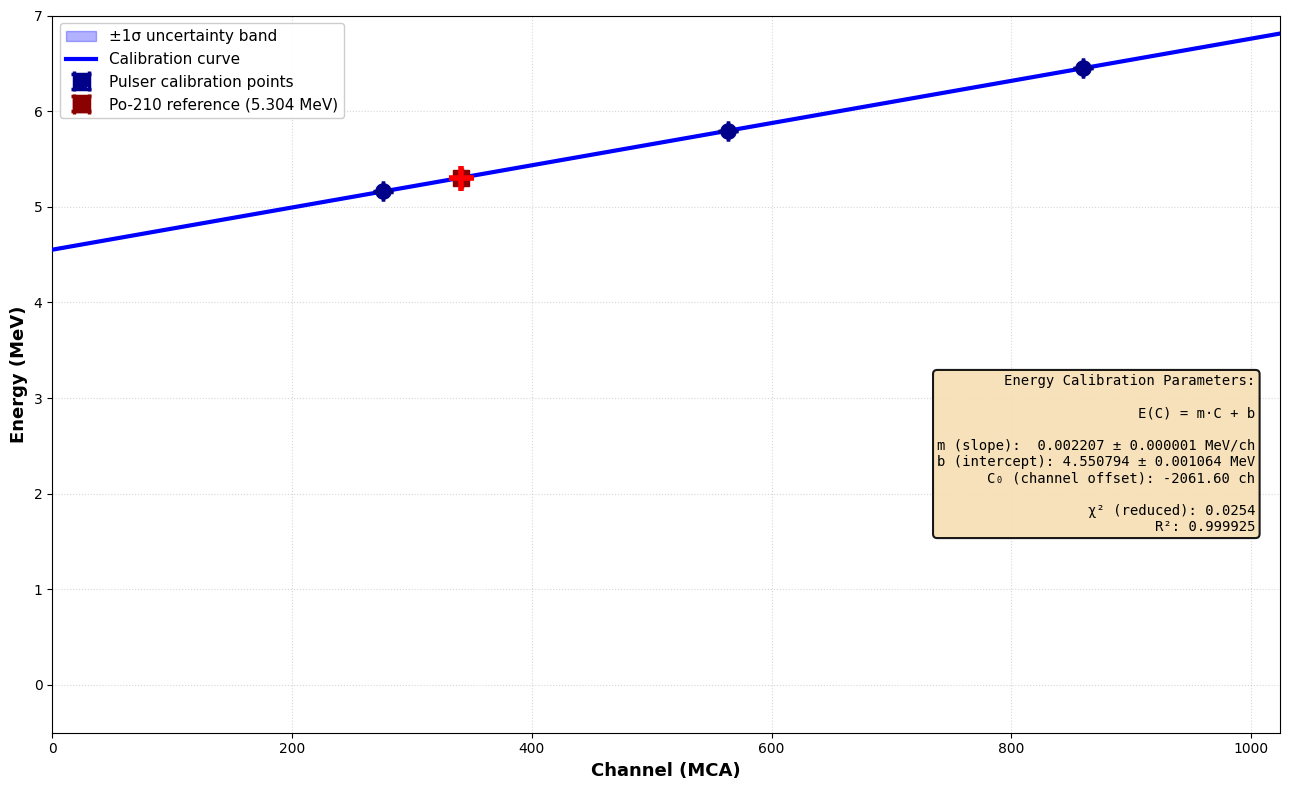

FINAL ENERGY CALIBRATION

Calibration Equation:
  E(C) = 0.002207 × C + 4.550794 MeV

Calibration Parameters:
  Gain (m):          0.002207 ± 0.000001 MeV/channel
  Intercept (b):     4.550794 ± 0.001064 MeV
  Channel offset:    -2061.60 channels

Goodness of Fit:
  χ² (reduced):      0.0254
  R²:                0.999925

Pulser Calibration Points (3):
  Point 1: 276.02 ± 0.015 ch  →  5.1601 ± 0.0016 MeV
  Point 2: 860.04 ± 0.015 ch  →  6.4492 ± 0.0018 MeV
  Point 3: 563.64 ± 0.015 ch  →  5.7950 ± 0.0017 MeV

Po-210 Reference Anchor:
  Measured: 341.22 ± 0.543 ch
  Calibrated: 5.3040 ± 0.0020 MeV
  Nominal:    5.304 MeV


In [30]:
# ==========================================
# FINAL ENERGY CALIBRATION PLOT
# ==========================================

fig, ax = plt.subplots(figsize=(13, 8))

# Plot range
canais_plot = np.linspace(0, 1024, 500)

# Central calibration line: E = m * C + b
energias_plot = ganho_energia * (canais_plot - c_zero_weighted)

# Uncertainty bands
sigma_E_plot = np.sqrt((sigma_ganho * (canais_plot - c_zero_weighted))**2 + 
                        (ganho_energia * sigma_c)**2 + 
                        sigma_b**2)

# Plot 1-sigma uncertainty band
ax.fill_between(canais_plot, energias_plot - sigma_E_plot, energias_plot + sigma_E_plot, 
                 alpha=0.3, color='blue', label='±1σ uncertainty band', zorder=1)

# Plot calibration line
ax.plot(canais_plot, energias_plot, 'b-', linewidth=3, label='Calibration curve', zorder=3)

# Plot pulser points with FULL error bars (X and Y)
ax.errorbar(centroides_pulser, energias_pulser_calibradas, 
            yerr=sigma_pulser_energia, xerr=sigma_pulser_array,
            fmt='o', color='darkblue', markersize=11, capsize=7, capthick=2.5, elinewidth=2.5,
            label='Pulser calibration points', zorder=4)

# Plot Po-210 reference point with error bars
ax.errorbar(centroide_po_medio_weighted, energia_po_calibrada, 
            yerr=sigma_po_calibrada, xerr=sigma_po_medio,
            fmt='s', color='darkred', markersize=12, capsize=7, capthick=2.5, elinewidth=2.5,
            label=f'Po-210 reference ({energia_po_real} MeV)', zorder=4)

# Nominal Po-210 energy (target point)
ax.plot(centroide_po_medio_weighted, energia_po_real, 'r+', markersize=18, markeredgewidth=4, zorder=5)

# Formatting
ax.set_xlabel('Channel (MCA)', fontsize=13, fontweight='bold')
ax.set_ylabel('Energy (MeV)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1024)
ax.set_ylim(-0.5, 7)
ax.grid(True, linestyle=':', alpha=0.5, zorder=0)
ax.legend(fontsize=11, loc='upper left', framealpha=0.98)

# Calibration parameters box
textstr = f'Energy Calibration Parameters:\n\n' \
          f'E(C) = m·C + b\n\n' \
          f'm (slope):  {ganho_energia:.6f} ± {sigma_ganho:.6f} MeV/ch\n' \
          f'b (intercept): {b_energia:.6f} ± {sigma_b:.6f} MeV\n' \
          f'C₀ (channel offset): {c_zero_weighted:.2f} ch\n\n' \
          f'χ² (reduced): {reduced_chi_sq:.4f}\n' \
          f'R²: {r_quadrado_weighted:.6f}'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black', linewidth=1.5)
ax.text(0.98, 0.50, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

print("="*70)
print("FINAL ENERGY CALIBRATION")
print("="*70)
print(f"\nCalibration Equation:")
print(f"  E(C) = {ganho_energia:.6f} × C + {b_energia:.6f} MeV")
print(f"\nCalibration Parameters:")
print(f"  Gain (m):          {ganho_energia:.6f} ± {sigma_ganho:.6f} MeV/channel")
print(f"  Intercept (b):     {b_energia:.6f} ± {sigma_b:.6f} MeV")
print(f"  Channel offset:    {c_zero_weighted:.2f} channels")
print(f"\nGoodness of Fit:")
print(f"  χ² (reduced):      {reduced_chi_sq:.4f}")
print(f"  R²:                {r_quadrado_weighted:.6f}")
print(f"\nPulser Calibration Points (3):")
for i, (ch, E, sig_ch, sig_E) in enumerate(zip(centroides_pulser, energias_pulser_calibradas, 
                                                  sigma_pulser_array, sigma_pulser_energia), 1):
    print(f"  Point {i}: {ch:.2f} ± {sig_ch:.3f} ch  →  {E:.4f} ± {sig_E:.4f} MeV")
print(f"\nPo-210 Reference Anchor:")
print(f"  Measured: {centroide_po_medio_weighted:.2f} ± {sigma_po_medio:.3f} ch")
print(f"  Calibrated: {energia_po_calibrada:.4f} ± {sigma_po_calibrada:.4f} MeV")
print(f"  Nominal:    {energia_po_real} MeV")
